#LIMPIEZA DE DATOS CLIMA
Este código se utiliza para limpiar y preparar bases de datos climáticas obtenidas de la Comisión Nacional del Agua (CONAGUA). En él se revisa la estructura de los datos, se identifican y tratan valores faltantes y atípicos, y se genera una nueva base de datos limpia para su posterior análisis.

In [1]:
# 0) Librerías
import numpy as np      # Para trabajar con operaciones numéricas y arreglos
import pandas as pd     # Para manejar los datos en forma de tablas (DataFrame)
import matplotlib.pyplot as plt  # Para graficar los datos


In [5]:
# 1) Subir y leer la base de datos (Excel)

from google.colab import files  # Permite subir archivos desde tu computadora a Colab

uploaded = files.upload()  # Abre el explorador para seleccionar el archivo
base_de_datos = list(uploaded.keys())[0]  # Obtiene el nombre del archivo subido

Saving TEMPERATURA MEDIA MENSUAL - LA BARCA.xlsx to TEMPERATURA MEDIA MENSUAL - LA BARCA.xlsx


**Nota sobre la base de datos:**
El archivo que se carga debe ser un Excel (.xlsx) que contenga información de UNA sola zona
(por ejemplo: Ocotlán, Jamay, La Barca, etc.) y de UNA sola variable climática
(como lluvia, temperatura o evaporación).
Este código está diseñado específicamente para trabajar con ese tipo de estructura.

In [7]:
# 1.a) Renombrar archivo y cargar datos

df = pd.read_excel(base_de_datos)  # Lee el archivo de Excel y lo guarda como DataFrame
nombre = base_de_datos.replace(".xlsx","")  # Elimina la extensión .xlsx para usar el nombre base

In [8]:
# 2) Diagnóstico básico de la base de datos

df.info()  # Muestra información general del DataFrame (columnas, tipos de datos y valores no nulos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AÑO     41 non-null     int64  
 1   ENE     36 non-null     float64
 2   FEB     37 non-null     float64
 3   MAR     34 non-null     float64
 4   ABR     34 non-null     float64
 5   MAY     34 non-null     float64
 6   JUN     35 non-null     float64
 7   JUL     39 non-null     float64
 8   AGO     37 non-null     float64
 9   SEP     36 non-null     float64
 10  OCT     35 non-null     float64
 11  NOV     36 non-null     float64
 12  DIC     35 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 4.3 KB


In [9]:
# 3) Revisar valores nulos en la base de datos

df.isnull().sum()  # Cuenta cuántos valores faltantes (NaN) hay en cada columna

,0
AÑO,0
ENE,5
FEB,4
MAR,7
ABR,7
MAY,7
JUN,6
JUL,2
AGO,4
SEP,5


In [10]:
# 4) Calcular cantidad y porcentaje de valores nulos

tabla_nulos = pd.DataFrame({ #crear una tabla de los datos nulos
    "Nulos": df.isnull().sum(),  # Número de valores faltantes por columna
    "Porcentaje": df.isnull().mean() * 100  # Porcentaje de nulos respecto al total
})

tabla_nulos["Porcentaje"] = tabla_nulos["Porcentaje"].round(2)  # Redondea a 2 decimales
tabla_nulos  # Muestra la tabla con el resumen de nulos

,Nulos,Porcentaje
AÑO,0,0.00
ENE,5,12.20
FEB,4,9.76
MAR,7,17.07
ABR,7,17.07
MAY,7,17.07
JUN,6,14.63
JUL,2,4.88
AGO,4,9.76
SEP,5,12.20


Aquí calculamos el porcentaje de valores nulos en cada columna con respecto al total de datos. Esto nos permite evaluar qué tan grande es la cantidad de datos faltantes y decidir si es conveniente imputarlos o si sería mejor considerar otra estrategia de tratamiento de datos.

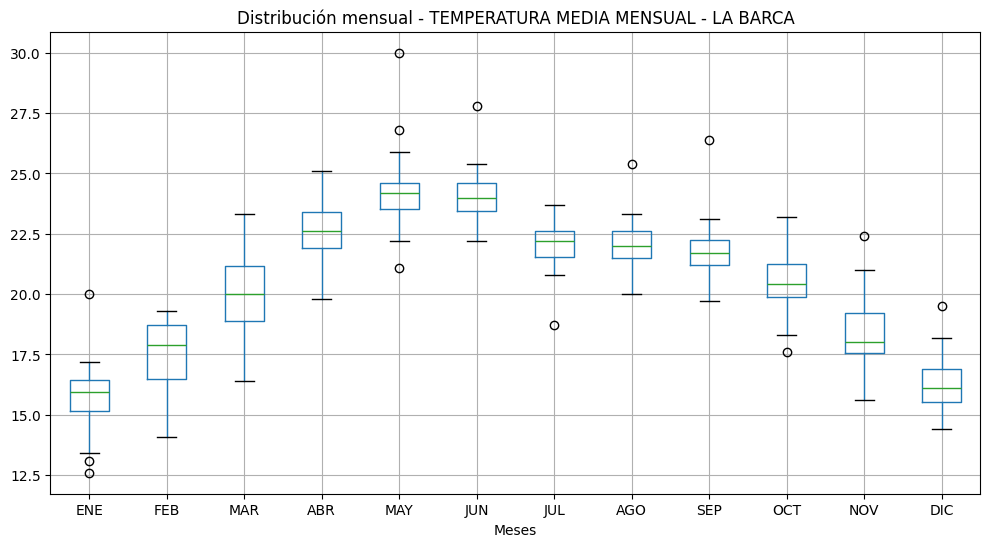

In [12]:
# 5) Boxplot de cada columna (distribución por mes)

plt.figure(figsize=(12,6))  # Define el tamaño de la gráfica (ancho, alto) en pulgadas

df.boxplot(column=['ENE','FEB','MAR','ABR','MAY','JUN','JUL','AGO','SEP','OCT','NOV','DIC'])

plt.title(f"Distribución mensual - {nombre}")  # Usa el nombre del archivo como título
plt.xlabel("Meses")  # Etiqueta general para los meses
plt.show()

Aquí utilizamos diagramas de caja (boxplots) para visualizar la distribución de los datos y detectar posibles valores atípicos (outliers), tanto muy altos como muy bajos. Esto permite evaluar si existen valores extremos que puedan afectar el análisis y decidir si es conveniente ajustarlos o aplicar algún método de tratamiento de outliers.

In [13]:
# 6) Calcular el percentil 95 de cada columna

q95 = df.quantile(0.95)  # Obtiene el valor por debajo del cual se encuentra el 95% de los datos
q95  # Muestra los valores del percentil 95 por columna

,0.95
AÑO,2022.000
ENE,17.125
FEB,19.020
MAR,23.035
ABR,24.380
MAY,26.215
JUN,25.330
JUL,23.230
AGO,23.220
SEP,23.100


In [14]:
# 7) Calcular el percentil 5 de cada columna

q05 = df.quantile(0.05)  # Obtiene el valor por debajo del cual se encuentra el 5% de los datos
q05  # Muestra los valores del percentil 5 por columna

,0.05
AÑO,1983.000
ENE,13.325
FEB,14.640
MAR,17.155
ABR,20.195
MAY,22.200
JUN,22.370
JUL,21.070
AGO,20.900
SEP,20.450


Para el tratamiento de valores atípicos se aplicó una winsorización, es decir, una técnica que consiste en limitar los valores extremos sustituyéndolos por valores dentro de un rango definido mediante percentiles. En este caso, se utilizaron los percentiles 5 y 95 como umbrales, lo que permite reducir la influencia de valores extremadamente altos o bajos sin eliminar observaciones ni alterar significativamente la distribución general de los datos, preservando así la variabilidad natural de la serie.

In [15]:
# 8) Aplicar winsorización (recorte de valores extremos)

meses = ['ENE','FEB','MAR','ABR','MAY','JUN','JUL','AGO','SEP','OCT','NOV','DIC']  # Lista de columnas a tratar
df_clipped = df.copy()  # Crea una copia del DataFrame original para no modificarlo directamente

df_clipped[meses] = df_clipped[meses].clip(
    lower=df_clipped[meses].quantile(0.05),  # Límite inferior (percentil 5)
    upper=df_clipped[meses].quantile(0.95),  # Límite superior (percentil 95)
    axis=1  # Aplica los límites por columna
                  #axis=0 → trabaja por filas
                 #axis=1 → trabaja por columnas
)

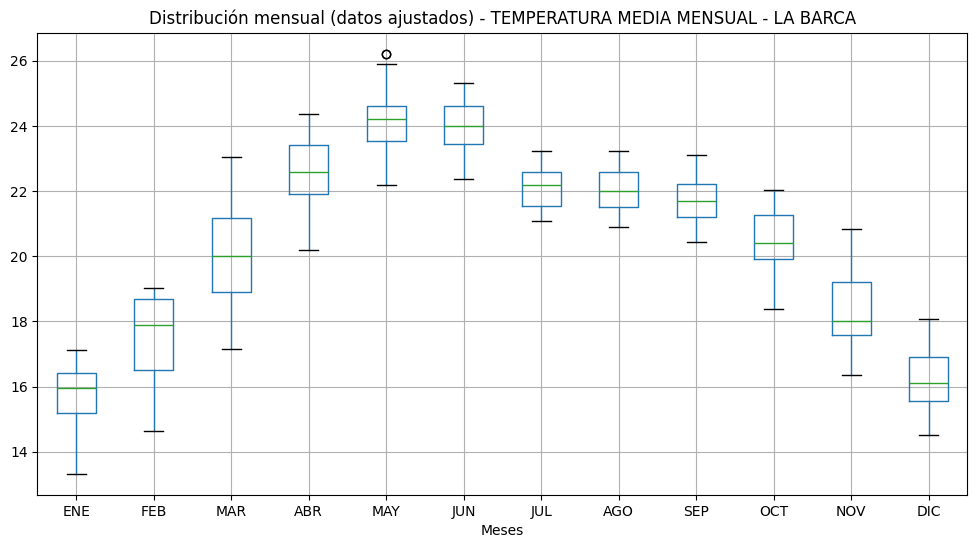

In [20]:
# 9) Verificar visualmente la distribución después de la winsorización

plt.figure(figsize=(12,6))

df_clipped.boxplot(column=['ENE','FEB','MAR','ABR','MAY','JUN','JUL','AGO','SEP','OCT','NOV','DIC'])

plt.title(f"Distribución mensual (datos ajustados) - {nombre}")  # Título dinámico con nombre del archivo
plt.xlabel("Meses")  # Etiqueta general
plt.show()

In [21]:
# 10) Generar base final con imputación de valores faltantes

df_imputado = df_clipped.copy()  # Crea una copia con los datos ya winsorizados
df_imputado[meses] = df_imputado[meses].fillna(df_imputado[meses].mean())  # Reemplaza los valores nulos por el promedio de cada columna

Se optó por imputar los valores faltantes utilizando la media de cada columna, ya que el porcentaje de datos faltantes es bajo y manejable. Este método permite conservar la tendencia central de la información sin introducir sesgos importantes ni distorsionar el comportamiento general de la variable. Además, al tratarse de variables climáticas, se asume que presentan variaciones naturales alrededor de un promedio, por lo que la imputación por media resulta una aproximación adecuada para mantener la coherencia de la serie y facilitar su análisis posterior.

In [22]:
# 11) Verificar que ya no existan valores nulos después de la imputación

df_imputado.isnull().sum()  # Cuenta los valores faltantes para confirmar que todos fueron reemplazados

,0
AÑO,0
ENE,0
FEB,0
MAR,0
ABR,0
MAY,0
JUN,0
JUL,0
AGO,0
SEP,0


Con esto se completa el proceso de limpieza de datos. Primero, se redujo el impacto de valores atípicos mediante la winsorización, limitando los extremos sin eliminar observaciones. Posteriormente, se imputaron los valores faltantes utilizando la media de cada columna, asegurando que la base de datos quedara completa. De esta manera, se obtiene un conjunto de datos más estable, consistente y listo para su análisis posterior.

In [23]:
# 12) Descargar la base de datos limpia

nombre_limpio = base_de_datos.replace(".xlsx", " limpia.csv")  # Genera un nuevo nombre para el archivo limpio
df_imputado.to_csv(nombre_limpio, index=False)  # Guarda el DataFrame final como archivo CSV

from google.colab import files
files.download(nombre_limpio)  # Descarga el archivo a tu computadora

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>